In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Desktop/Telco Customer Churn dataset/Telco-Customer-Churn.csv")

df.head() 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
# Part 2 - Exploring the Dataset Structure
# Task 4
print("Shape:", df.shape)
df.dtypes

Shape: (7043, 21)


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [18]:
# Task 5
df[['customerID']].head()
print("TotalCharges dtype:", df['TotalCharges'].dtype)

TotalCharges dtype: object


In [19]:
# Task 6
for c in ['Contract', 'PaymentMethod', 'InternetService']:
    print(c, ":", df[c].unique())

Contract : ['Month-to-month' 'One year' 'Two year']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
InternetService : ['DSL' 'Fiber optic' 'No']


In [20]:
# Part 3 — Investigating Data Quality 
# Task 7
print(df.isnull().sum())
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print("Blank TotalCharges rows:", blank_mask.sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Blank TotalCharges rows: 11


In [21]:
# Task 8
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df['customerID'].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0


In [22]:
# Task 9
df.loc[blank_mask, ['customerID','tenure','MonthlyCharges','TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [24]:
# Part 4 — Data Cleaning Decisions
# Task 11 : apply cleaning
clean = df.copy()
clean['TotalCharges'] = pd.to_numeric(clean['TotalCharges'], errors='coerce')
clean['TotalCharges'] = clean['TotalCharges'].fillna(0)

#Task 11 continued: confirm cleaning worked
print(clean['TotalCharges'].dtype)
print(clean['TotalCharges'].isnull().sum())
print(clean.duplicated().sum())


float64
0
0


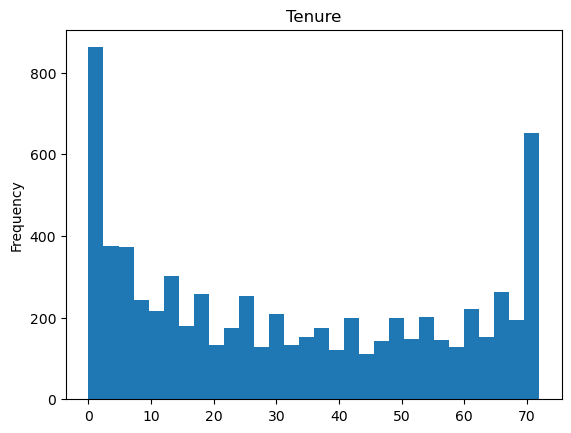

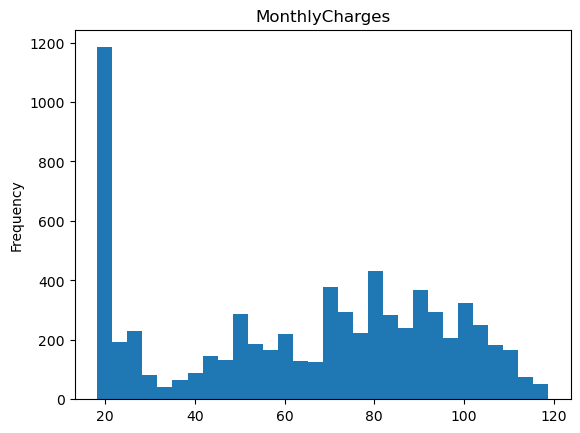

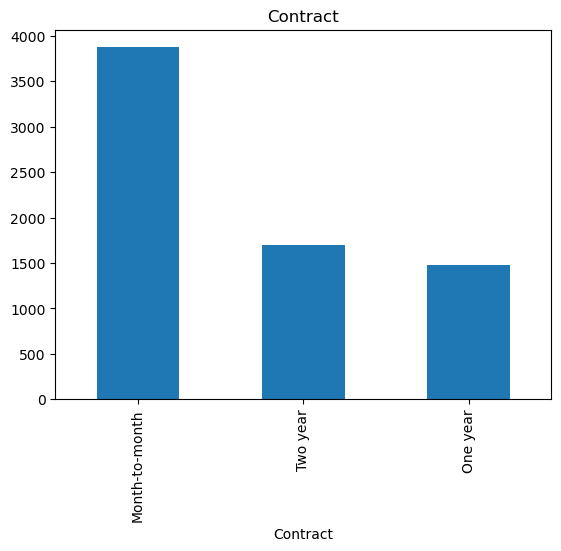

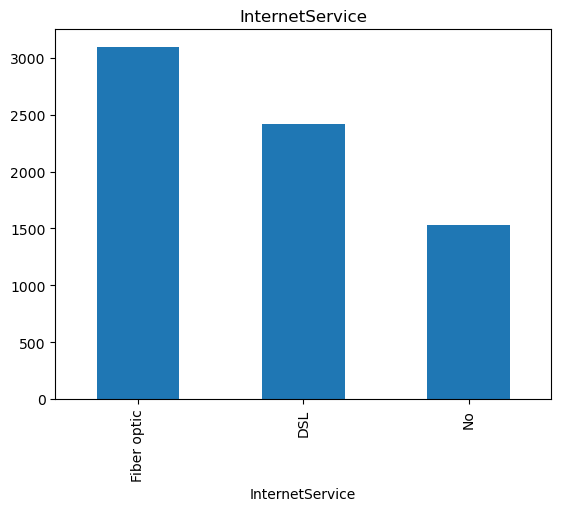

In [25]:
# Part 5 — Univariate EDA
# Task 12: 2 numeric + 2 categorical charts
clean['tenure'].plot(kind='hist', bins=30); plt.title('Tenure'); plt.show()
clean['MonthlyCharges'].plot(kind='hist', bins=30); plt.title('MonthlyCharges'); plt.show()
clean['Contract'].value_counts().plot(kind='bar'); plt.title('Contract'); plt.show()
clean['InternetService'].value_counts().plot(kind='bar'); plt.title('InternetService'); plt.show()


In [27]:
# Part 6 — Target Variable Analysis 
# Task 14: churn counts and percentages
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [28]:
# Part 7 — Bivariate Analysis: Features vs. Churn
# Task 16: 2 categorical features vs Churn
pd.crosstab(clean['Contract'], clean['Churn'], normalize='index')*100
pd.crosstab(clean['InternetService'], clean['Churn'], normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


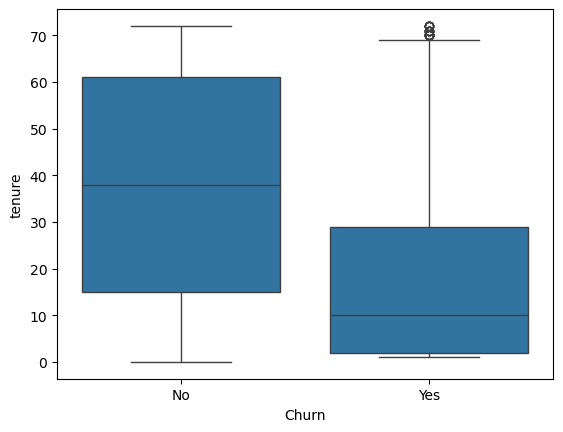

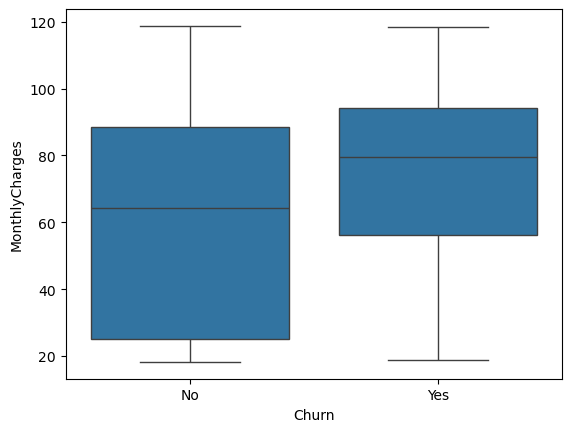

In [30]:
# Task 17: 2 numerical features vs Churn
sns.boxplot(x='Churn', y='tenure', data=clean); plt.show()
sns.boxplot(x='Churn', y='MonthlyCharges', data=clean); plt.show()

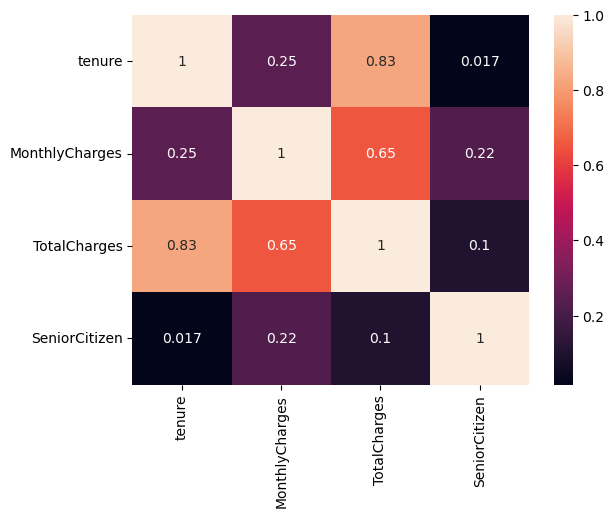

In [31]:
# Part 8 — Correlation & Feature Relationships 
# Task 18: correlation matrix and heatmap
corr = clean[['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']].corr()
sns.heatmap(corr, annot=True)
plt.show()

In [33]:
# Part 11 — Building the Clean Dataset 
# Task 23: build clean_df and save
clean_df = df.copy()
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce').fillna(0)
clean_df.to_csv("clean_churn.csv", index=False)

In [34]:
# Task 24: final proof
clean_df.info()
print(clean_df.isnull().sum().sum())
print(clean_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
